Date : 02/02/2026

### 🌟 Feature Scaling
✅ What is Feature Scaling?

Feature Scaling = Converting all input features into the same scale (range) so that ML algorithms work properly and faster.

Because ML algorithms compare numbers.  
If one feature has very big values and another has small values, the model becomes biased.

❌ Problem without Feature Scaling

Example dataset:

| Height (cm) | Weight (kg) |
| ----------- | ----------- |
| 160         | 55          |
| 180         | 75          |

Height range = 150–190  
Weight range = 40–90

Algorithms like KNN, SVM, Logistic Regression, Gradient Descent use distance → so large values dominate small ones ❌  

✅ Why Feature Scaling is needed?

- Improves accuracy
- Faster training
- Avoids bias toward large-value features

Required for:

- KNN
- SVM
- Logistic Regression
- Neural Networks
- PCA

Not mandatory for:

- Decision Tree
- Random Forest

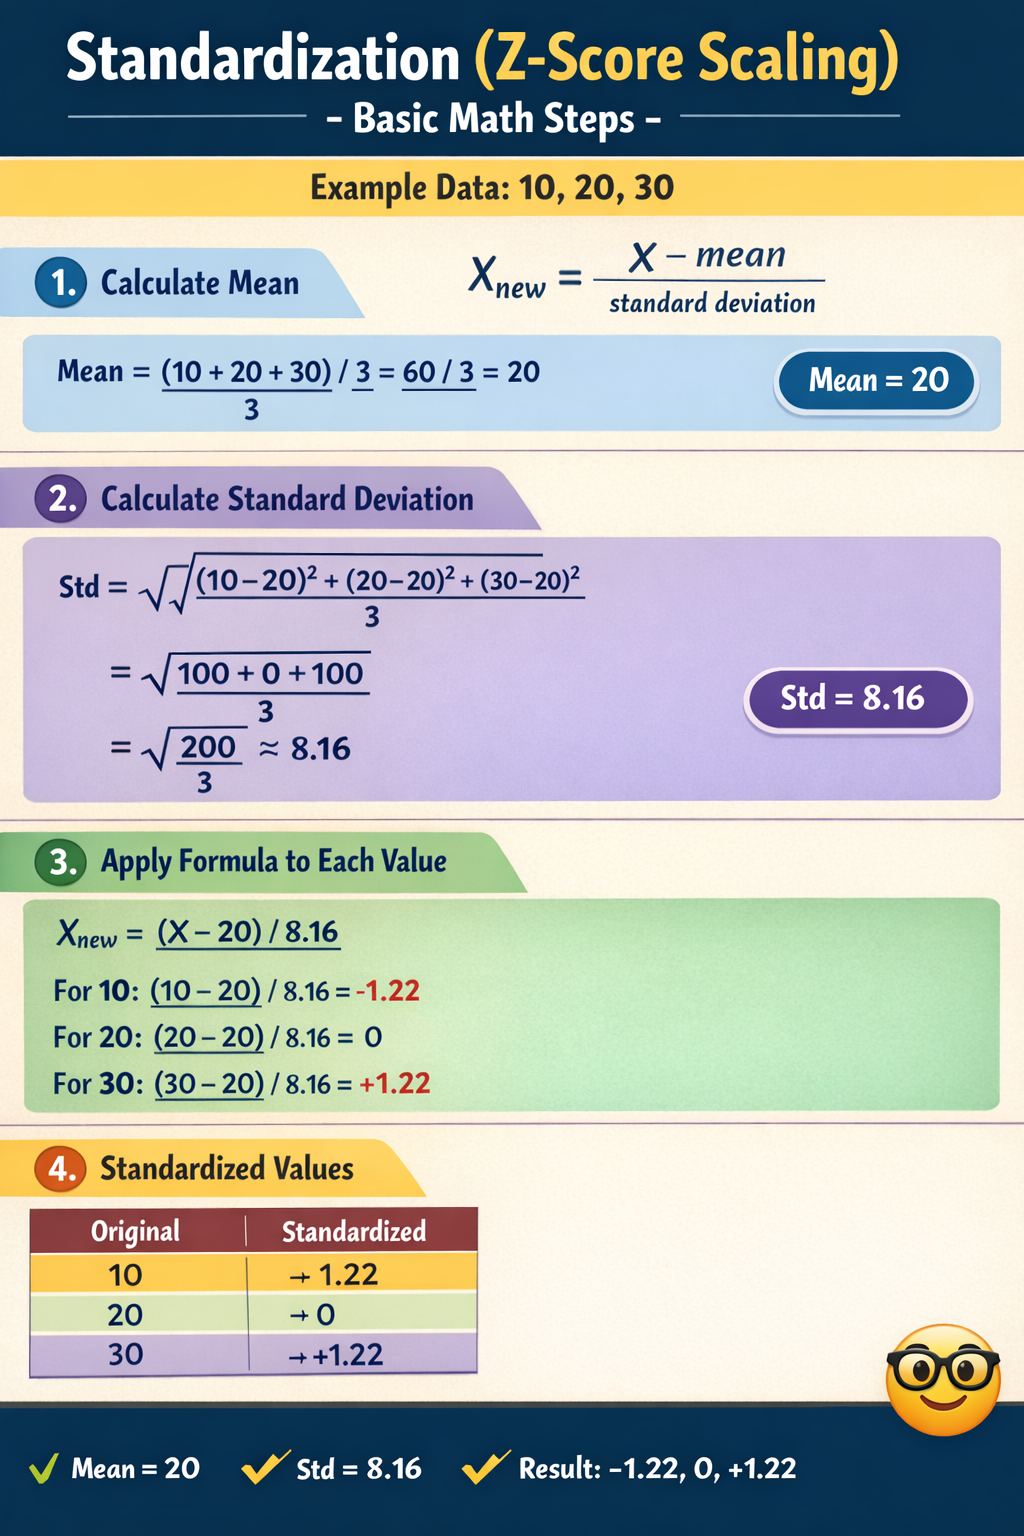

In [92]:
import numpy as np      # linear algebra
import pandas as pd     # data processing
import matplotlib.pyplot as plt
import seaborn as sns

In [93]:
df = pd.read_csv('Social_Network_Ads.csv')

In [94]:
print(df.head())

    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0


Train-Test split

In [95]:
'''
    Meaning:
        X = what model learns from
        y = what model predicts
'''

x = df[['Age', 'EstimatedSalary']]
y = df['Purchased']

🌟Why we split the data?

If we train on full data, model will memorize it.

So we split into:

Training data → to teach the model  
Testing data → to check accuracy on new data

Usually:

80% training  
20% testing

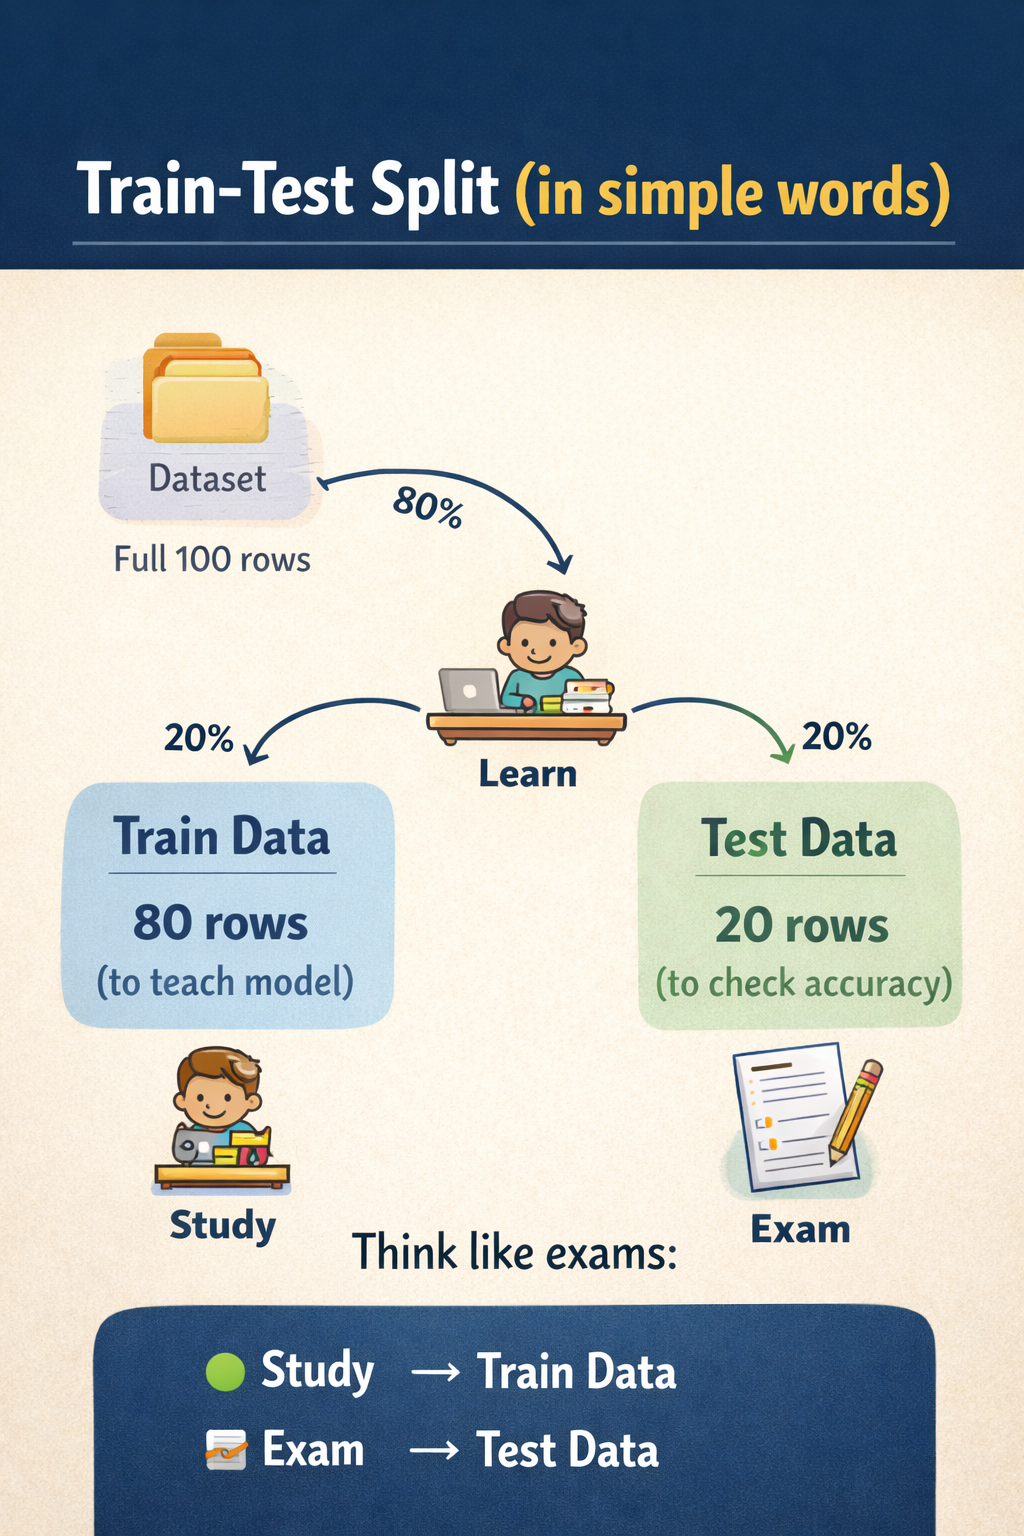

In [96]:
from sklearn.model_selection import train_test_split

In [97]:
''' 
    test_size=0.2 means 20% of the data will be used for testing and 80% for training.
    random_state=42 is used to ensure that the split of the data into training and testing sets is reproducible.
    By setting random_state to a specific value (in this case, 42), 
    you ensure that every time you run the code, you will get the same split of the data, 
    which is important for consistency and debugging purposes.
'''

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [98]:
'''
    here X_train means or indicates the training data for features (i.e., input variables) 
    which is age and estimated salary 
    in this case. y_train indicates the training data for the target variable (i.e., output variable) 
    which is whether the user purchased or not.

    and X_test and y_test are the corresponding test datasets for features and target variable, respectively.
    means it is used to evaluate the performance of the model after it has been trained on the training data.
'''

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (320, 2)
X_test shape: (80, 2)
y_train shape: (320,)
y_test shape: (80,)


Standardization

In [99]:
from sklearn.preprocessing import StandardScaler

In [100]:
'''
    working of StandardScaler: 
    1. It calculates the mean and standard deviation of each feature in the training data.
    2. It then transforms the data by subtracting the mean and dividing by the standard deviation for each feature.
    3. This results in a new dataset where each feature has a mean of 0 and a standard deviation of 1.
    4. The same transformation is applied to the test data using the mean and standard deviation
        calculated from the training data to ensure that the test data is scaled in the same way as the training data.
'''

scaler = StandardScaler()       

In [101]:
''' 
    fit is used for to calculate minimum and maximum value it learns from the data
    and transform is used to scale that data using the mean and standard deviation calculated during fit.
'''

x_scaled = scaler.fit_transform(x)

In [102]:
# output shows the scaled version of the original features (Age and EstimatedSalary) where each feature has been standardized to have a mean of 0 and a standard deviation of 1.
x_scaled 

array([[-1.78179743, -1.49004624],
       [-0.25358736, -1.46068138],
       [-1.11320552, -0.78528968],
       [-1.01769239, -0.37418169],
       [-1.78179743,  0.18375059],
       [-1.01769239, -0.34481683],
       [-1.01769239,  0.41866944],
       [-0.54012675,  2.35674998],
       [-1.20871865, -1.07893824],
       [-0.25358736, -0.13926283],
       [-1.11320552,  0.30121002],
       [-1.11320552, -0.52100597],
       [-1.6862843 ,  0.47739916],
       [-0.54012675, -1.51941109],
       [-1.87731056,  0.35993973],
       [-0.82666613,  0.30121002],
       [ 0.89257019, -1.3138571 ],
       [ 0.70154394, -1.28449224],
       [ 0.79705706, -1.22576253],
       [ 0.98808332, -1.19639767],
       [ 0.70154394, -1.40195167],
       [ 0.89257019, -0.60910054],
       [ 0.98808332, -0.84401939],
       [ 0.70154394, -1.40195167],
       [ 0.79705706, -1.37258681],
       [ 0.89257019, -1.46068138],
       [ 1.08359645, -1.22576253],
       [ 0.89257019, -1.16703281],
       [-0.82666613,

In [103]:
'''
    here we convert x_scaled is numpy array then we convert it into pandas dataframe
    because describe() method is a pandas method that provides a statistical summary of the DataFrame,
    and then we use describe() method to get the statistical summary of the scaled features.
'''

pd.DataFrame(x_scaled).describe()

,0,1
count,4.000000e+02,4.000000e+02
mean,-7.105427e-17,-1.776357e-17
std,1.001252e+00,1.001252e+00
min,-1.877311e+00,-1.607506e+00
25%,-7.550313e-01,-7.852897e-01
50%,-6.256110e-02,7.561451e-03
75%,7.970571e-01,5.361289e-01
max,2.134241e+00,2.356750e+00


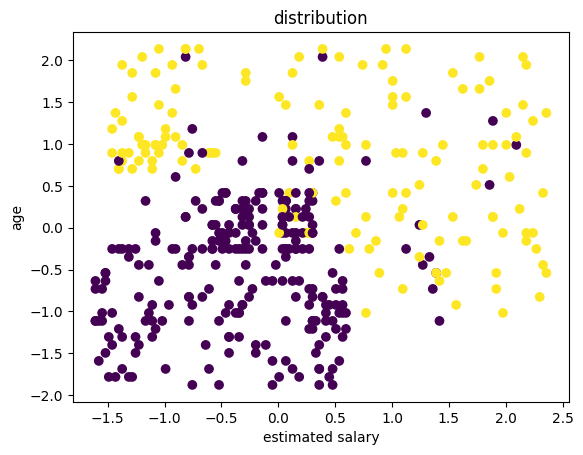

In [104]:
'''
    plt.scatter(X-axis values, Y-axis values, color)
    [:, 1] all rows and 1st column (estimated salary)
    [:, 0] all rows and 0th column (age)
    c means color and we are using the 'Purchased' column to color the points in the scatter plot,
    which indicates whether the user purchased or not.
'''

plt.title("distribution")
plt.xlabel("estimated salary")
plt.ylabel("age")
plt.scatter(x_scaled[:, 1], x_scaled[:, 0], c = df['Purchased'])

In [105]:
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [106]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [107]:
# for standardization we have to imort StandardScaler and for normalization we have to import MinMaxScaler
# from sklearn.preprocessinng

Normalization

In [108]:
from sklearn.preprocessing import MinMaxScaler

In [109]:
scaler = MinMaxScaler()

In [110]:
''' 
    fit(x) -> Finds the minimum (min) and maximum (max) value of each column in x.
    transform(x) -> Then it applies this formula to every value:
        x(new) = x-min/max-min
        So all values become between 0 and 1.
'''

x_scaled = scaler.fit_transform(x)

In [111]:
x_scaled

array([[0.02380952, 0.02962963],
       [0.4047619 , 0.03703704],
       [0.19047619, 0.20740741],
       [0.21428571, 0.31111111],
       [0.02380952, 0.45185185],
       [0.21428571, 0.31851852],
       [0.21428571, 0.51111111],
       [0.33333333, 1.        ],
       [0.16666667, 0.13333333],
       [0.4047619 , 0.37037037],
       [0.19047619, 0.48148148],
       [0.19047619, 0.27407407],
       [0.04761905, 0.52592593],
       [0.33333333, 0.02222222],
       [0.        , 0.4962963 ],
       [0.26190476, 0.48148148],
       [0.69047619, 0.07407407],
       [0.64285714, 0.08148148],
       [0.66666667, 0.0962963 ],
       [0.71428571, 0.1037037 ],
       [0.64285714, 0.05185185],
       [0.69047619, 0.25185185],
       [0.71428571, 0.19259259],
       [0.64285714, 0.05185185],
       [0.66666667, 0.05925926],
       [0.69047619, 0.03703704],
       [0.73809524, 0.0962963 ],
       [0.69047619, 0.11111111],
       [0.26190476, 0.20740741],
       [0.30952381, 0.02222222],
       [0.

In [112]:
'''
    here we are checking the maximum and minimum value of the first column (age) after scaling using MinMaxScaler.
    since MinMaxScaler scales the data to be between 0 and 1, 
    we expect the maximum value to be 1 and the minimum value to be 0.
'''

x_scaled[:, 0].max(), x_scaled[:, 0].min()

(np.float64(0.9999999999999998), np.float64(0.0))

In [113]:
'''
    here we are checking the maximum and minimum value of the second column (estimated salary) after scaling using MinMaxScaler.
    since MinMaxScaler scales the data to be between 0 and 1, 
    we expect the maximum value to be 1 and the minimum value to be 0.
'''

x_scaled[:, 1].max(), x_scaled[:, 1].min()

(np.float64(1.0), np.float64(0.0))

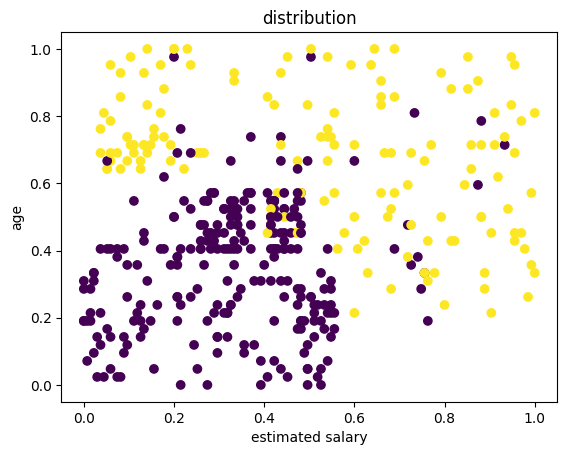

In [114]:
plt.title("distribution")
plt.xlabel("estimated salary")
plt.ylabel("age")
plt.scatter(x_scaled[:, 1], x_scaled[:, 0], c = df['Purchased']);

| Feature               | Standardization           | Normalization                    |
| --------------------- | ------------------------- | -------------------------------- |
| Range                 | No fixed range            | 0 to 1                           |
| Mean                  | 0                         | Not necessarily 0                |
| Standard deviation    | 1                         | Not fixed                        |
| Formula               | (x − mean) / std          | (x − min) / (max − min)          |
| Negative values       | Yes                       | No                               |
| Sensitive to outliers | Yes                       | Yes                              |
| Best for              | Regression, SVM, PCA, KNN | Neural Networks, KNN, Image data |
| Scaler used           | StandardScaler            | MinMaxScaler                     |